<a href="https://colab.research.google.com/github/July230/AviDetect/blob/develop/AviDetectClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Librerías

In [1]:
!pip install split-folders

In [2]:
import os
import shutil
import splitfolders
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras import optimizers
from tensorflow.keras import models
from tensorflow.keras import layers
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.applications import DenseNet201, DenseNet121, InceptionV3, ResNet50
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Path de Google Drive

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


Usaremos el dataset [Drone vs Bird:Aerial Object Classification Dataset](https://www.kaggle.com/datasets/muhammadsaoodsarwar/drone-vs-bird) disponible públicamente [Kaggle](https://www.kaggle.com) bajo la licencia **Apache 2.0**.

Podemos importar el dataset vía kagglehub.

In [4]:
# Download latest version
path = kagglehub.dataset_download("muhammadsaoodsarwar/drone-vs-bird")

print("Path to dataset files:", path)

100%|██████████| 1.59G/1.59G [00:13<00:00, 123MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/muhammadsaoodsarwar/drone-vs-bird/versions/1


El dataset tiene dos carpetas con 4106 imágenes en total:
* bird: 1607 imágenes
* drone: 2499 imágenes

Es necesario hacer el split inicial para obtener train y test. Posteriormente, dividir train en train y validation. Las divisiones comunes para esta división son 70/15/15 u 80/10/10.
Haremos una división de 70% train, 15% validation y 15% test.

In [ ]:
def removeDirectories(parentDirectory, directoriesToRemove):
  """
  Remove the directories of a parent directory

  Parameters
  ----------
  parentDirectory : str
    Path to the parent directory you want to clean
  directoriesToRemove : list
    List of the directories to clean

  Returns
  -------
  None
  """
  for directory in directoriesToRemove:
    directoryPath = os.path.join(parentDirectory, directory)
    if os.path.exists(directoryPath):
      shutil.rmtree(directoryPath)
      print(f"Deleted: {directoryPath}")

Tomaremos el dataset de kaggle y el dataset resultado (spliteado) estará en el directorio BirdVSDrone

In [5]:
SEED = 42
# parentDirectory = "/content/drive/MyDrive/ProyectoIndividual"
parentDirectory = "/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual"
datasetDirectory = os.path.join(path, "dataset")
outputDirectory = os.path.join(parentDirectory, "BirdVSDrone")

In [ ]:
!ls {datasetDirectory}

bird  drone


Eliminamos las carpetas para replicar el experimento de preprocesamiento

In [ ]:
directoriesToRemove = ["train", "test", "val"]
removeDirectories(outputDirectory, directoriesToRemove)

Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/test
Deleted: /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/val


La librería splitfolders permite hacer el split de manera sencilla, se hace la división 70% para entrenamiento, 15% para validación y 15% para pruebas

In [ ]:
splitfolders.ratio(datasetDirectory, output=outputDirectory, seed=SEED, ratio=(0.7, 0.15, 0.15))

Copying files: 4106 files [00:53, 76.62 files/s]


Dato curioso: La semilla 42 se usa en ocasiones como tradición de programadores y científicos de datos. Aparece de la novela de ciencia ficción de Douglas Adams: *La guía del autoestopista galáctico (1979)*. Aquí, la supercomputadora llamada *Deep though* revela que la respuesta a la gran pregunta de "la vida, el universo y todo lo demás" es 42. Realmente no tiene alguna ventaja computacional.

Verificamos que existan los directorios e imágenes imagenes

In [ ]:
!ls {outputDirectory}

test  train  val


In [ ]:
def countImages(directory, directories):
  """
  Count the number of images in a directory

  Parameters
  ----------
  directory : str
    Path to the directory where the images are
  directories : list
    Directories train, test and val that have bird and drone each

  Returns
  -------
  None
  """
  for directory in directories:
    print(f"Images in {directory}:")
    for subdirectory in ["bird", "drone"]:
      totalImages = len(os.listdir(os.path.join(outputDirectory, directory, subdirectory)))
      print(f"{subdirectory}: {totalImages}")

In [ ]:
directoriesWithImages = ["train", "test", "val"]
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1124
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


Visualizamos las imagenes que hay en train

In [6]:
trainDirectory = os.path.join(outputDirectory, "train")
testDirectory = os.path.join(outputDirectory, "test")
valDirectory = os.path.join(outputDirectory, "val")

In [ ]:
def getImages(directory, numImages, seed=42):
  """
  Get the images from a directory and show them

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  numImages : int
    Images to show

  Returns
  -------
  None
  """

  np.random.seed(seed)

  plt.figure(figsize=(10,10))
  images = [i for i in os.listdir(directory) if os.path.isfile(os.path.join(directory, i))]
  np.random.shuffle(images)
  images = images[:numImages]

  for i, image in enumerate(images):
    img = plt.imread(os.path.join(directory, image))
    plt.subplot(4,4,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(img, cmap=plt.cm.binary)

  plt.show()

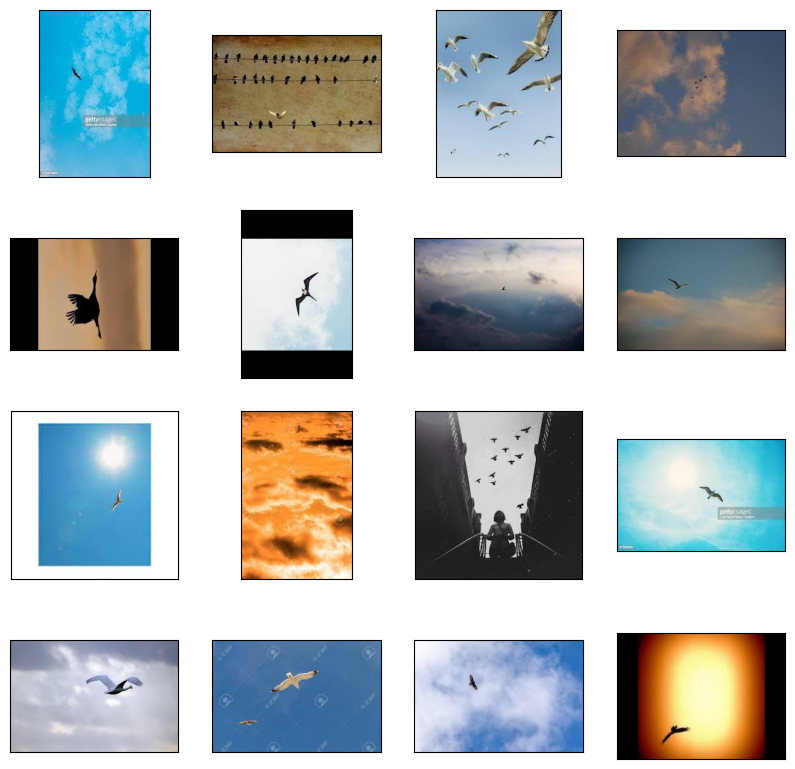

In [ ]:
getImages(os.path.join(trainDirectory, "bird"), 16, SEED)

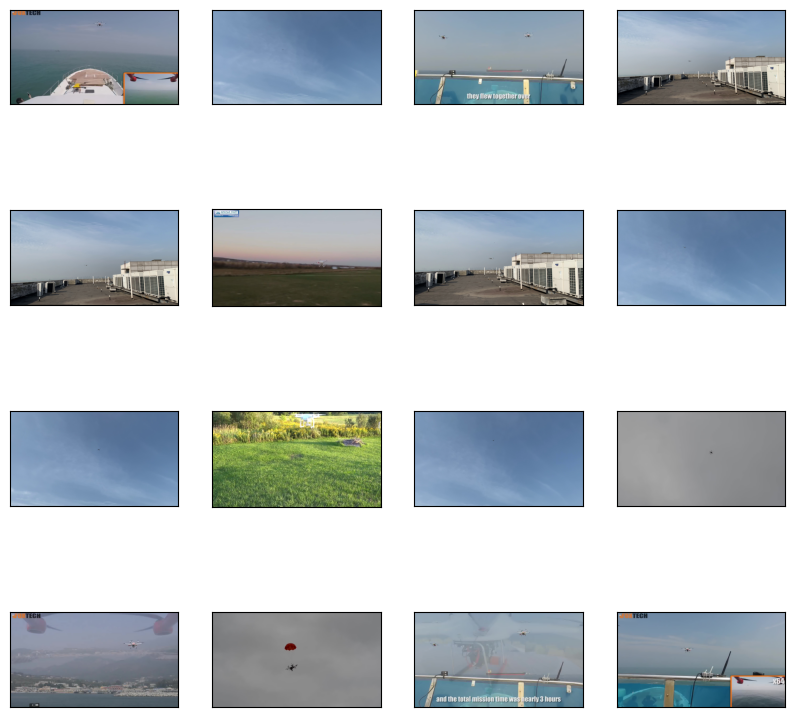

In [ ]:
getImages(os.path.join(trainDirectory, "drone"), 16, SEED)

# Desbalanceo de clases y data augmentation
El dataset contiene más imágenes de drones que de aves, lo que puede derivar en que el modelo aprenda más a identificar drones que aves.
Para mitigar el desbalanceo de clases, se consideró una técnica de oversampling sobre la clase minoritaria, seguido de data augmentation a todas las clases, siguiendo enfoques similares a los propuestos por Guerrero et al. (2024), donde la aumentación dirigida permitió reducir el sesgo hacia las clases mayoritarias en tareas de clasificación de imágenes.
Es importante destacar que estas alteraciones en el dataset se hacen únicamente en el set de entrenamiento. Los set de validation y test se dejan como están.

Se realizó un oversampling aleatorio. Se calcularon las imágenes faltantes, seleccionando la misma cantidad aleatoriamente y duplicando cada imagen una vez.

In [ ]:
def oversample(directory, minorClass, mayorClass, seed=42):
  """
  Selects images randomly and copies in the same directory

  Parameters
  ----------
  directory : str
    Path to the directory that contains the train set
  minorClass : str
    Minority class foldername
  mayorClass : str
    Mayority class foldername
  seed : int
    Random seed

  Returns
  -------
  None
  """

  mayorClassPath = os.path.join(directory, mayorClass)
  minorClassPath = os.path.join(directory, minorClass)

  mayorImages = sorted([i for i in os.listdir(mayorClassPath) if os.path.isfile(os.path.join(mayorClassPath, i))])
  minorImages = sorted([i for i in os.listdir(minorClassPath) if os.path.isfile(os.path.join(minorClassPath, i))])

  lenMayorImages = len(mayorImages)
  lenMinorImages = len(minorImages)
  imagesNeeded = lenMayorImages - lenMinorImages

  print(f"{mayorClass}: {lenMayorImages}")
  print(f"{minorClass}: {lenMinorImages}")
  print(f"Need to generate: {imagesNeeded}")

  if mayorImages == []:
    print(f"{mayorImages} has no images.")
    return

  if minorImages == []:
    print(f"{minorClassPath} has no images.")
    return

  if imagesNeeded <= 0:
    print(f"Dataset already balanced.")
    return

  np.random.seed(seed)
  selectedImages = np.random.choice(minorImages, size=imagesNeeded, replace=True)

  for index, image in enumerate(selectedImages):
    sourcePath = os.path.join(minorClassPath, image)
    filename, extension = os.path.splitext(image)
    newFileName = f"{filename}_copy_{index}{extension}"
    destinationPath = os.path.join(minorClassPath, newFileName)
    shutil.copy2(sourcePath, destinationPath)
  print(f"Generated {imagesNeeded} oversampled images in {minorClassPath}")


In [ ]:
oversample(trainDirectory, 'bird', 'drone', seed=SEED)

drone: 1749
bird: 1124
Need to generate: 625
Generated 625 oversampled images in /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/BirdVSDrone/train/bird


Verificamos que se haya hecho el oversampling en train

In [ ]:
countImages(outputDirectory, directoriesWithImages)

Images in train:
bird: 1749
drone: 1749
Images in test:
bird: 242
drone: 376
Images in val:
bird: 241
drone: 374


# Data augmentation
Después de aplicar oversampling, se usa ImageDataGenerator para generar imagenes nuevas en el ram mientras se entrena para no desperdiciar espacio. Un problema de tamaño limitado de se presentó a los autores Rares Ilie Orzan et al (2024) donde contaban con una cantidad limitada de imágenes (106) para su estudio. Aplicaron una serie de transformaciones a las imágenes para combatir la falta de datos.

In [ ]:
# Constants
IMAGEWIDTH = 224
IMAGEHEIGHT = 224
BATCHSIZE = 16
ROTATIONRANGE = 30
TRANSLATIONS = 0.1
SCALING = [0.9, 1.1]
EPOCHS = 14

In [ ]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False)

Para ello se asigna una fuente base de imágenes a modificar, se toman sólo las del directorio de train. En este caso sólo se toma una imagen y se muestra como se generarían 5 imágenes diferentes.

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

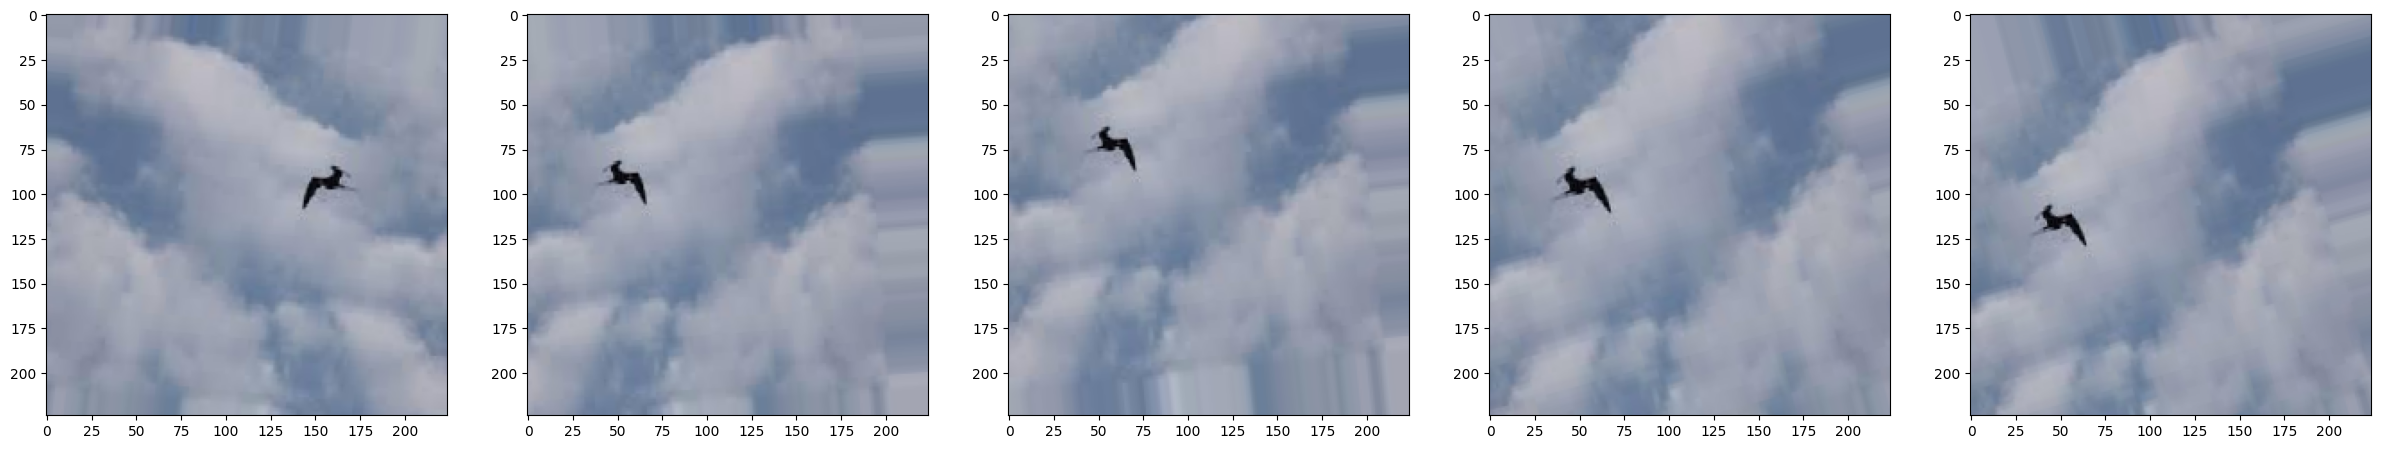

In [ ]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(16, 224, 224, 3)
[0. 1. 1. 0. 0. 0. 0. 1. 0. 0. 0. 1. 0. 1. 0. 0.]


<Figure size 640x480 with 0 Axes>

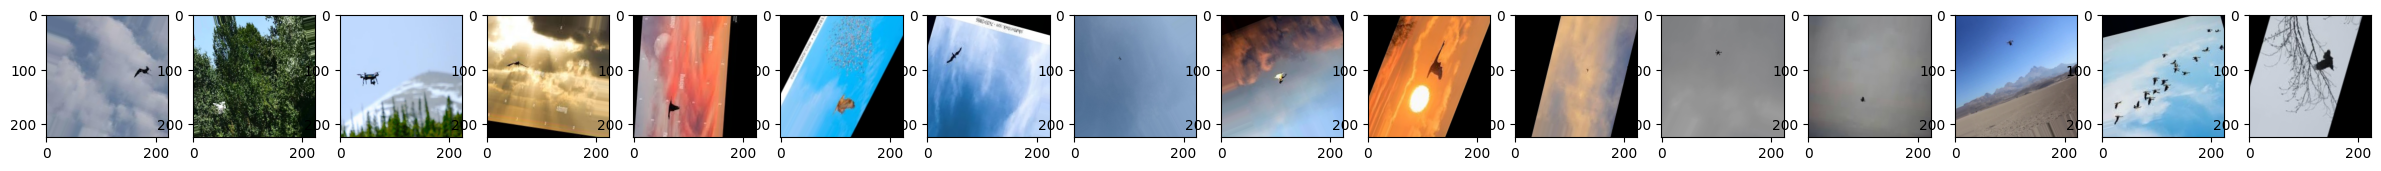

In [ ]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 6))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

Con validation y test sólo se probará con lo real, sin embargo, sí se escala. Ya que no se entrena con datos de validación y prueba, establecemos shuffle como False para comparar correctamente con las etiquetas reales y así evitar resultados caóticos o incorrectos

In [ ]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary",
    shuffle = False)

Found 615 images belonging to 2 classes.


In [ ]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary",
    shuffle = False)

Found 618 images belonging to 2 classes.


# Primera Red Neuronal Convolutiva (CNN)
Se crea la red neuronal convolutiva. Con la capa convolutiva se convierten las características de dos dimensiones (las imágenes) en matrices con las características más singnificativas. Posteriormente se convierte en un vector de una dimensión.

Este modelo se hizo basado en la documentación de tensorflow. Las dimensiones de ancho y alto tienden a reducirse a medida que se profundiza en la red. El número de canales de salida para cada capa Conv2D está controlado por el primer argumento.

In [ ]:
def getModelCompiled():
  """
  Creates the model and compiles it

  Parameters
  ----------
  None

  Returns
  -------
  model : keras.models.Sequential
    Compiled model
  """
  model = models.Sequential()
  model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Conv2D(64, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Conv2D(128, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Flatten())
  model.add(layers.Dense(128,activation="relu"))
  model.add(layers.Dense(1,activation="sigmoid"))

  model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"])

  return model

In [ ]:
ThreeLayerCNN = getModelCompiled()
ThreeLayerCNN.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
%cd {parentDirectory}

/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual


In [ ]:
%ls

AviDetectClassifier.ipynb  BirdVSDrone/  checkpoints/


In [ ]:
!mkdir "checkpoints"

mkdir: cannot create directory ‘checkpoints’: File exists


In [ ]:
checkpointDirectory = os.path.join(parentDirectory, "checkpoints")
checkpointThreeLayerCNNPath = os.path.join(checkpointDirectory, "ThreeLayerCNN", "checkpoint.weights.h5")
checkpointThreeLayerCNN = ModelCheckpoint(
    filepath = checkpointThreeLayerCNNPath,
    save_weights_only = True,
    save_freq = "epoch",
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1)

In [ ]:
ThreeLayerCNNHistory = ThreeLayerCNN.fit(
    trainGenerator,
    validation_data = valGenerator,
    epochs = EPOCHS,
    callbacks = [checkpointThreeLayerCNN],
    verbose = True)

Epoch 1/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6865 - loss: 0.6289

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.48293, saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/checkpoints/ThreeLayerCNN/checkpoint.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/checkpoints/ThreeLayerCNN/checkpoint.weights.h5
219/219 ━━━━━━━━━━━━━━━━━━━━ 108s 478ms/step - accuracy: 0.7462 - loss: 0.5123 - val_accuracy: 0.4829 - val_loss: 126.4581
Epoch 2/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.8051 - loss: 0.4621
Epoch 2: val_accuracy did not improve from 0.48293
219/219 ━━━━━━━━━━━━━━━━━━━━ 103s 473ms/step - accuracy: 0.8155 - loss: 0.4210 - val_accuracy: 0.3919 - val_loss: 305.4071
Epoch 3/14
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8456 - loss: 0.3546
Epoch 3: val_accuracy improved from 0.48293 to 0.54146, saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanza

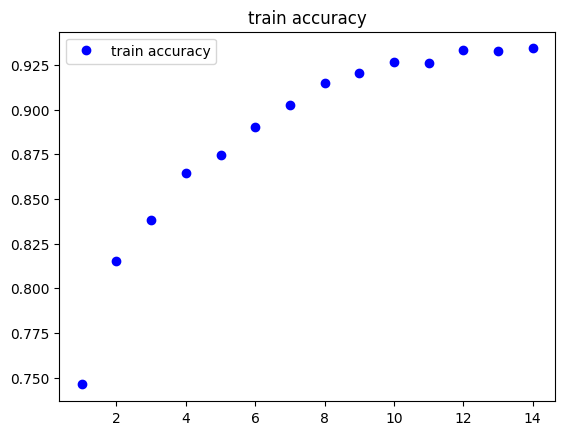

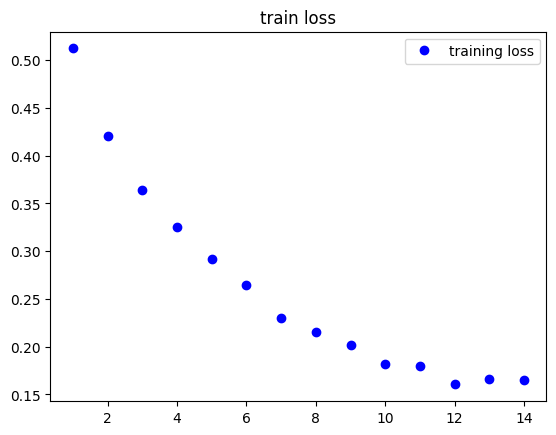

In [ ]:
trainAccuracy = ThreeLayerCNNHistory.history["accuracy"]
trainLoss = ThreeLayerCNNHistory.history["loss"]

epochs = range(1, len(trainAccuracy)+1)

plt.plot(epochs, trainAccuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, trainLoss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

<Axes: >

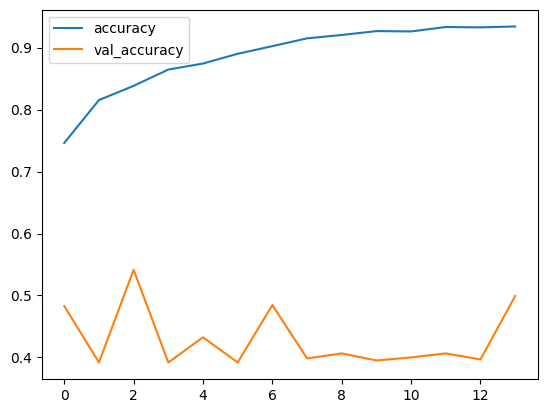

In [ ]:
ThreeLayerCNNDF = pd.DataFrame(ThreeLayerCNNHistory.history)
ThreeLayerCNNDF.plot(y=["accuracy", "val_accuracy"])

In [ ]:
# Inspect the checkpoint directory
!ls -lh {checkpointDirectory}

total 4.0K
drwx------ 2 root root 4.0K May 31 23:58 ThreeLayerCNN


Ya que queremos medir el mejor modelo que se obtuvo, cargamos los pesos.

In [ ]:
ThreeLayerCNNBest = getModelCompiled()
ThreeLayerCNNBest.load_weights(checkpointThreeLayerCNNPath)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
valLoss, valAccuracy = ThreeLayerCNNBest.evaluate(valGenerator)
print("\nval accuracy :\n", valAccuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 313ms/step - accuracy: 0.5415 - loss: 93.8722

val accuracy :
 0.5414634346961975


In [ ]:
testLoss, testAccuracy = ThreeLayerCNNBest.evaluate(testGenerator)
print("\ntest acc :\n", testAccuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.5372 - loss: 88.1224

test acc :
 0.53721684217453


## Comparando resultados

El estado del arte en el problema de clasificación de aves y drones es un acuracy, precision, recall y F1-score mayores a 90% utilizando arquitecturas preentrenadas.

In [7]:
def confusionMatrix(model, setGenerator):
  """
  Creates the confusion matrix based on real and predicted labels

  Parameters
  ----------
  model : keras.models.Sequential
    Model to evaluate
  setGenerator : keras.preprocessing.image.ImageDataGenerator
    Image generator

  Returns
  -------
  mat : np.ndarray
    Confusion matrix
  """
  predictions = model.predict(setGenerator)
  trueLabels = setGenerator.classes
  predictedClasses = (predictions > 0.5).astype(int).flatten()
  matrix = confusion_matrix(trueLabels, predictedClasses)

  print("\t\t", "label negative", "label positive")
  print("prediction negative\t", np.array(matrix[0][0]), "\t", np.array(matrix[0][1]))
  print("prediction positive\t", np.array(matrix[1][0]), "\t", np.array(matrix[1][1]))

  return matrix

def displayConfusionMatrix(confusionMatrix):
  """
  Displays the confusion matrix

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  display = ConfusionMatrixDisplay(
      confusion_matrix=confusionMatrix,
      display_labels=["Bird", "Drone"])
  display.plot()
  plt.title("Confusion matrix")
  plt.show()

def metrics(confusionMatrix):
  """
  Calculates the metrics based on the confusion matrix
  Accuracy, Precision, Recall and F1-score

  Parameters
  ----------
  confusionMatrix : np.ndarray
    Confusion matrix

  Returns
  -------
  None
  """
  truePositives = confusionMatrix[1][1]
  trueNegatives = confusionMatrix[0][0]
  falsePositives = confusionMatrix[0][1]
  falseNegatives = confusionMatrix[1][0]

  accuracy = (truePositives + trueNegatives) / (truePositives + trueNegatives + falsePositives + falseNegatives)
  precision = truePositives / (truePositives + falsePositives)
  recall = truePositives / (truePositives + falseNegatives)
  f1Score = (2 * (precision * recall)) / (precision + recall)

  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision: {precision:.4f}")
  print(f"Recall: {recall:.4f}")
  print(f"F1-score: {f1Score:.4f}")

Compararemos resultados del mejor modelo que se obtuvo durante la historia

### Train

In [ ]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", trainLoss, "\t", trainAccuracy)

Model		 Train loss		 Train Accuracy	
Original	 [0.5123379230499268, 0.4209791421890259, 0.3644077479839325, 0.3252982795238495, 0.2920819818973541, 0.2648043632507324, 0.2304147481918335, 0.2152603417634964, 0.2018602043390274, 0.18183913826942444, 0.179402157664299, 0.16044828295707703, 0.16617371141910553, 0.16473501920700073] 	 [0.7462088465690613, 0.8154506683349609, 0.8383404612541199, 0.8646637797355652, 0.8743919730186462, 0.8901287317276001, 0.9024320244789124, 0.9150214791297913, 0.9204577803611755, 0.926752507686615, 0.9261802434921265, 0.9333333373069763, 0.9327610731124878, 0.9341917037963867]


In [ ]:
confusionMatrixTrain = confusionMatrix(ThreeLayerCNNBest, trainGenerator)

219/219 ━━━━━━━━━━━━━━━━━━━━ 87s 396ms/step
		 label negative label positive
prediction negative	 695 	 1051
prediction positive	 667 	 1082


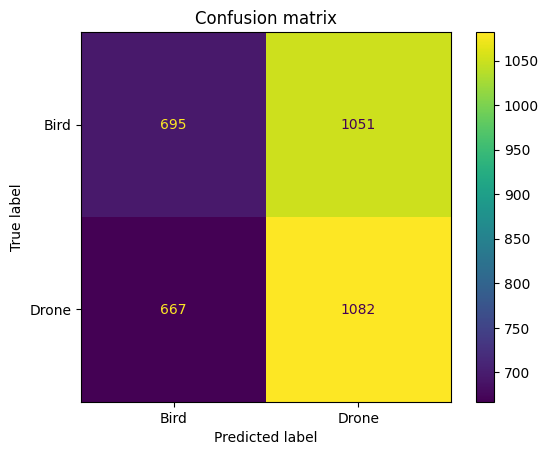

In [ ]:
displayConfusionMatrix(confusionMatrixTrain)

In [ ]:
metrics(confusionMatrixTrain)

Accuracy: 0.5084
Precision: 0.5073
Recall: 0.6186
F1-score: 0.5574


La metrica más baja es la precisión, algo esperado puesto que no acierta correctamente a la mayoría de las instancias de una clase, en este caso, bird. Es por esa razón que el recall es alto, ya que confunde mucho a la clase negativa. Como resultado, el F1-Score es muy bajo, al ser una media armónica de ambas métricas mencionadas, penaliza cuando una de las dos es baja.

### Validation

In [ ]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 93.87220001220703 	 0.5414634346961975


In [ ]:
confusionMatrixVal = confusionMatrix(ThreeLayerCNNBest, valGenerator)

39/39 ━━━━━━━━━━━━━━━━━━━━ 11s 275ms/step
		 label negative label positive
prediction negative	 233 	 8
prediction positive	 274 	 100


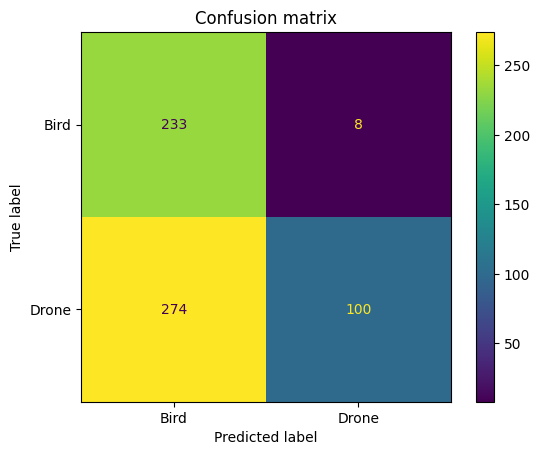

In [ ]:
displayConfusionMatrix(confusionMatrixVal)

In [ ]:
metrics(confusionMatrixVal)

Accuracy: 0.5415
Precision: 0.9259
Recall: 0.2674
F1-score: 0.4149


### Test

In [ ]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 88.12238311767578 	 0.53721684217453


In [ ]:
confusionMatrixTest = confusionMatrix(ThreeLayerCNNBest, testGenerator)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 10s 263ms/step
		 label negative label positive
prediction negative	 235 	 7
prediction positive	 279 	 97


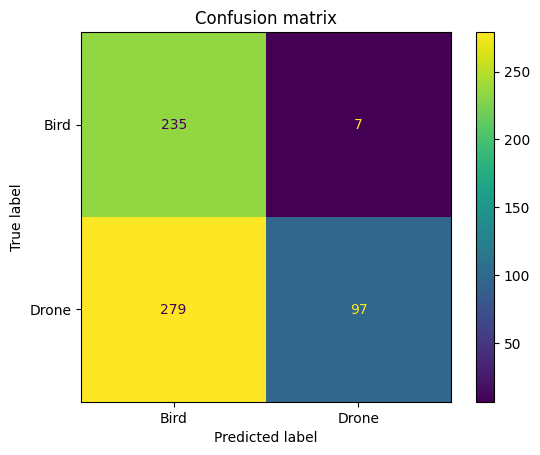

In [ ]:
displayConfusionMatrix(confusionMatrixTest)

In [ ]:
metrics(confusionMatrixTest)

Accuracy: 0.5372
Precision: 0.9327
Recall: 0.2580
F1-score: 0.4042


# Conclusiones y siguientes pasos
El modelo tuvo un desempeño deficiente en la tarea de clasificación entre aves y drones. Las métricas de evaluación empleadas muestran un comportamiento consistente entre los conjuntos de entrenamiento, validación y prueba con valores de accuracy cercanos al 50%, lo que indica una capacidad limitada al discriminar entre ambas clases.

En los conjuntos de validación y prueba casi no se registraron Falsos positivos, lo que llevó a una precisión apróximada de 92%. Sin embargo, el recall fue muy bajo, lo que significa que la mayoría de los drones fueron clasificados erróneamente como aves.

Estos resultados implican que, cuando se encuentra con instancias nunca vistas, el modelo detecta correctamente la clase bird pero no detecta una gran cantidad de instancias de la clase drone. En consecuencia, el valor de F1-score permanece bajo, lo que revela un equilibrio deficiente.

Los resultados evidencian un problema de subajuste, ya que el redimiento es similar en los tres conjuntos. El modelo presenta dificultades para aprender características que permitan separar adecuadamente ambas clases, es decir, su capacidad de generalización es insuficiente.

Comparándolo con el estado del arte en el problema de clasificación, el modelo actual no es lo suficientemente complejo para resolverlo.

Basado en estas observaciones, los siguientes pasos propuestos son incrementar la complejidad del modelo de forma que la dificultad del problema sea mejor tratada.

# Modelo con Arquitectura Modificada

Aprovechamos que ya contamos con el dataset dividido en los tres conjuntos. Cambiamos el tamaño de batch para este segundo modelo, por lo que se crea otra variable para las imagenes generadas con ese tamaño.


In [ ]:
BATCHSIZE = 32
EPOCHS = 14
LEARNINGRATE = 0.001

In [ ]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False)

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

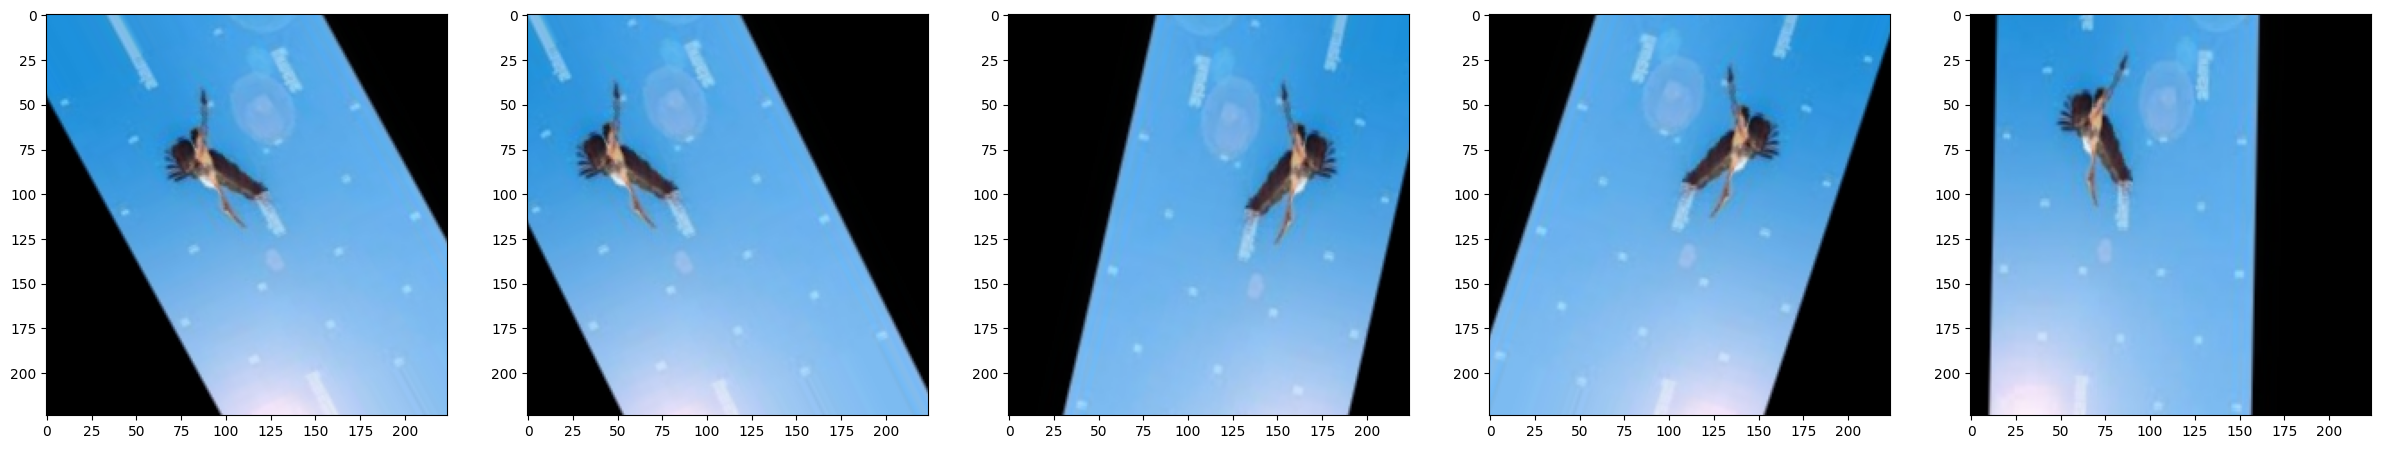

In [ ]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(32, 224, 224, 3)
[0. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0. 1. 0. 1. 1. 1. 1. 0. 1. 0.
 0. 1. 0. 0. 0. 1. 1. 1.]


<Figure size 640x480 with 0 Axes>

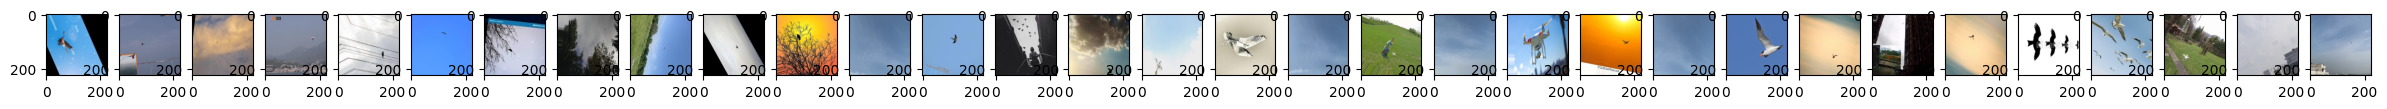

In [ ]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 6))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [ ]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary",
    shuffle = False)

Found 615 images belonging to 2 classes.


In [ ]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary",
    shuffle = False)

Found 618 images belonging to 2 classes.


Para este segundo modelo se modificó la arquitectura agregando capas Dropout y modificando learning rate. Como menciona el siguiente paper

In [ ]:
def getModelCompiledTunned():
  """
  Creates the second model and compiles it

  Parameters
  ----------
  None

  Returns
  -------
  model : keras.models.Sequential
    Compiled model
  """
  model = models.Sequential()
  model.add(layers.Conv2D(32, (3, 3), activation="relu", input_shape = (IMAGEWIDTH,IMAGEHEIGHT,3)))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Dropout(0.16))
  model.add(layers.Conv2D(64, (3, 3), activation="relu"))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Dropout(0.16))
  model.add(layers.Conv2D(128, (3, 3), activation="relu"))
  model.add(layers.MaxPooling2D((2, 2)))
  model.add(layers.Dropout(0.16))
  model.add(layers.Flatten())
  model.add(layers.Dense(128,activation="relu"))
  model.add(layers.Dropout(0.16))
  model.add(layers.Dense(1,activation="sigmoid"))

  model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=LEARNINGRATE),
    metrics=["accuracy"])

  return model

In [ ]:
ThreeLayerCNNTunned = getModelCompiledTunned()
ThreeLayerCNNTunned.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

Guardamos el modelo y su arquitectura con los mejores pesos

In [ ]:
checkpointDirectory = os.path.join(parentDirectory, "checkpoints")
checkpointThreeLayerCNNTunnedPath = os.path.join(checkpointDirectory, "ThreeLayerCNNTunned", "ThreeLayerCNNTunned.keras")
checkpointThreeLayerCNNTunned = ModelCheckpoint(
    filepath = checkpointThreeLayerCNNTunnedPath,
    save_weights_only = False,
    save_freq = "epoch",
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1)

In [ ]:
ThreeLayerCNNTunnedHistory = ThreeLayerCNNTunned.fit(
    trainGenerator,
    validation_data = valGenerator,
    epochs = EPOCHS,
    callbacks = [checkpointThreeLayerCNNTunned],
    verbose = True)

Epoch 1/14
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6045 - loss: 1.4086

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.70081, saving model to /content/drive/MyDrive/ProyectoIndividual/checkpoints/ThreeLayerCNNTunned/ThreeLayerCNNTunned.keras

Epoch 1: finished saving model to /content/drive/MyDrive/ProyectoIndividual/checkpoints/ThreeLayerCNNTunned/ThreeLayerCNNTunned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 1037s 9s/step - accuracy: 0.6916 - loss: 0.7554 - val_accuracy: 0.7008 - val_loss: 13.2108
Epoch 2/14
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 843ms/step - accuracy: 0.7708 - loss: 0.4500
Epoch 2: val_accuracy improved from 0.70081 to 0.72195, saving model to /content/drive/MyDrive/ProyectoIndividual/checkpoints/ThreeLayerCNNTunned/ThreeLayerCNNTunned.keras

Epoch 2: finished saving model to /content/drive/MyDrive/ProyectoIndividual/checkpoints/ThreeLayerCNNTunned/ThreeLayerCNNTunned.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 105s 955ms/step - accuracy: 0.7817 - loss: 0.4304 - val_accuracy: 0.7220 - val_loss: 41.0090
Epoch 3/14
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 859ms/step - ac

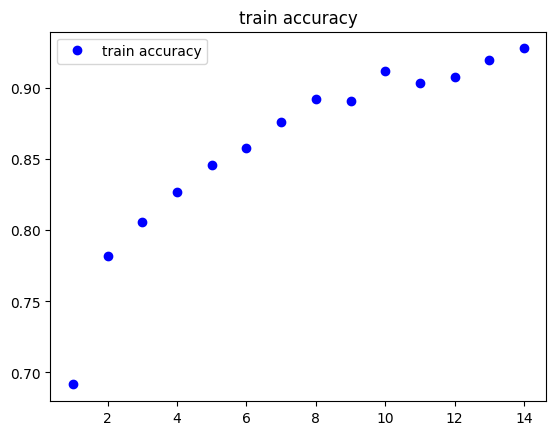

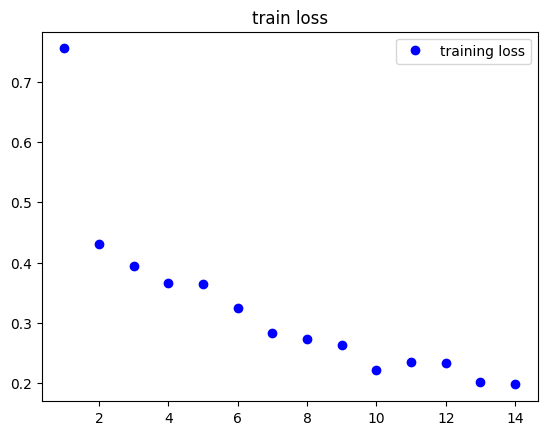

In [ ]:
trainAccuracy = ThreeLayerCNNTunnedHistory.history["accuracy"]
trainLoss = ThreeLayerCNNTunnedHistory.history["loss"]

epochs = range(1, len(trainAccuracy)+1)

plt.plot(epochs, trainAccuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, trainLoss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

<Axes: >

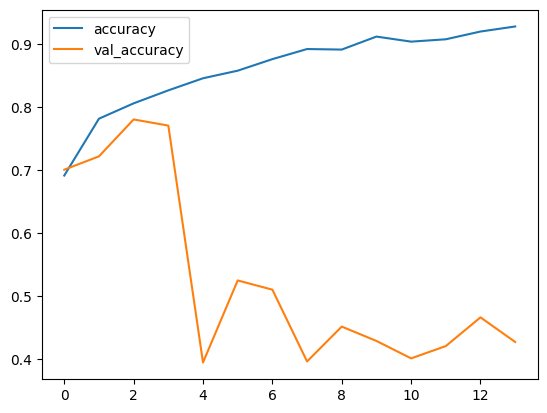

In [ ]:
ThreeLayerCNNTunnedDF = pd.DataFrame(ThreeLayerCNNTunnedHistory.history)
ThreeLayerCNNTunnedDF.plot(y=["accuracy", "val_accuracy"])

In [ ]:
# Inspect the checkpoint directory
!ls -lh {checkpointDirectory}

total 12K
drwx------ 2 root root 4.0K May 31 23:45 ThreeLayerCNN
drwx------ 2 root root 4.0K Jun  3 02:16 ThreeLayerCNNTunned
drwx------ 2 root root 4.0K Jun  2 01:15 ThreeLayerCNNTwo


In [ ]:
ThreeLayerCNNTunnedBest = models.load_model(checkpointThreeLayerCNNTunnedPath)

In [ ]:
valLoss, valAccuracy = ThreeLayerCNNTunnedBest.evaluate(valGenerator)
print("\nval accuracy :\n", valAccuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 13s 621ms/step - accuracy: 0.7805 - loss: 20.3083

val accuracy :
 0.7804877758026123


In [ ]:
testLoss, testAccuracy = ThreeLayerCNNTunnedBest.evaluate(testGenerator)
print("\ntest acc :\n", testAccuracy)

20/20 ━━━━━━━━━━━━━━━━━━━━ 241s 13s/step - accuracy: 0.7945 - loss: 14.8506

test acc :
 0.7944983839988708


## Comparando resultados
Compararemos resultados del mejor modelo que se obtuvo durante la historia

### Train

In [ ]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", trainLoss, "\t", trainAccuracy)

Model		 Train loss		 Train Accuracy	
Original	 [0.7554111480712891, 0.430426687002182, 0.3940263092517853, 0.36533141136169434, 0.3651670217514038, 0.3244325816631317, 0.28388112783432007, 0.2725673317909241, 0.2624301016330719, 0.22197695076465607, 0.23496882617473602, 0.23320740461349487, 0.20143234729766846, 0.19765403866767883] 	 [0.691559374332428, 0.7816881537437439, 0.8060085773468018, 0.8266094326972961, 0.8457796573638916, 0.857796847820282, 0.876108705997467, 0.8921316266059875, 0.8912732601165771, 0.9118741154670715, 0.9038626551628113, 0.9075822830200195, 0.9198855757713318, 0.9278969764709473]


110/110 ━━━━━━━━━━━━━━━━━━━━ 90s 813ms/step
		 label negative label positive
prediction negative	 656 	 1090
prediction positive	 669 	 1080


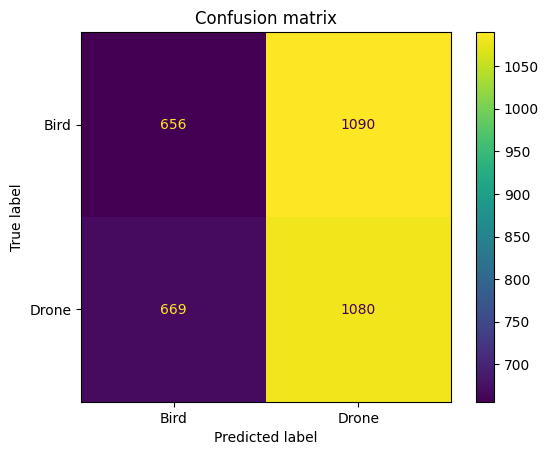

In [ ]:
confusionMatrixTrain = confusionMatrix(ThreeLayerCNNTunnedBest, trainGenerator)
displayConfusionMatrix(confusionMatrixTrain)

In [ ]:
metrics(confusionMatrixTrain)

Accuracy: 0.4967
Precision: 0.4977
Recall: 0.6175
F1-score: 0.5512


### Validation

In [ ]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 20.3083438873291 	 0.7804877758026123


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 592ms/step
		 label negative label positive
prediction negative	 199 	 42
prediction positive	 93 	 281


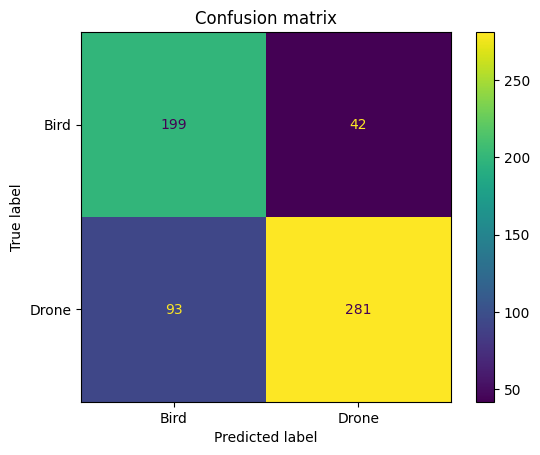

In [ ]:
confusionMatrixVal = confusionMatrix(ThreeLayerCNNTunnedBest, valGenerator)
displayConfusionMatrix(confusionMatrixVal)

In [ ]:
metrics(confusionMatrixVal)

Accuracy: 0.7805
Precision: 0.8700
Recall: 0.7513
F1-score: 0.8063


### Test

In [ ]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 14.850605010986328 	 0.7944983839988708


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 585ms/step
		 label negative label positive
prediction negative	 201 	 41
prediction positive	 86 	 290


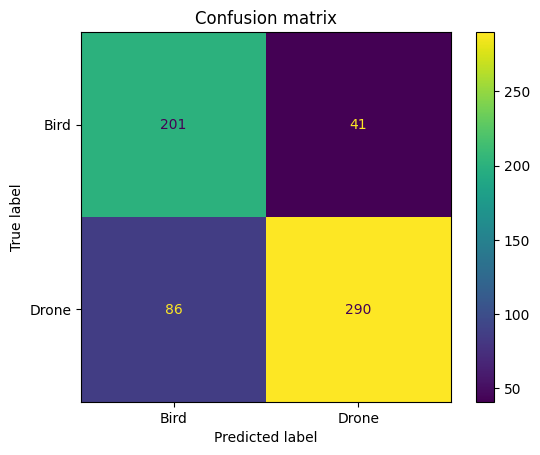

In [ ]:
confusionMatrixTest = confusionMatrix(ThreeLayerCNNTunnedBest, testGenerator)
displayConfusionMatrix(confusionMatrixTest)

In [ ]:
metrics(confusionMatrixTest)

Accuracy: 0.7945
Precision: 0.8761
Recall: 0.7713
F1-score: 0.8204


# Conclusiones y siguientes pasos
El modelo tuvo un mejor desempeño en la tarea de clasificación entre aves y drones. Similar al modelo anterior, las métricas muestran un comportamiento similar en los conjuntos de validación y prueba, ahora con valores cercanos al 79%, lo que indica una mejor capacidad al discriminar entre ambas clases.

En los conjuntos de validación y prueba se registraron más falsos positivos, lo que llevó a una precisión aproximada de 87%. Sin embargo, en esta ocasión el recall aumentó considerablemente hasta alcanzar valores cercanos al 76%, lo que significa que hubo más drones identificados correctamente pero al mismo tiempo hubo más aves clasificadas incorrectamente.

Estos resultados implican que el modelo tiene una mejor capacidad de generalización con respecto al anterior, balanceando la tasa de falsos positivos y falsos negativos. En consecuencia, el valor de F1-score aumento, lo que revela un equilibrio mejor.

La incorporación de dropout layers en conjunto al cambio de tamaño de batch y establecimiento de un learning rate fijo llevó a que el modelo desarrollara una mejor capacidad de generalización.

Sin embargo, comparándolo con el estado del arte en el problema de clasificación de aves y drones, el modelo continua siendo insuficiente para llegar a una buena solución.

Basado en estas observaciones, los siguientes pasos propuestos son incrementar la complejidad del modelo mediante la incorporación de aprendizaje transferido usando alguna de las arquitecturas existentes como VGG16, VGG19, InceptionV3, RestNet, EfficientNetB4, entre otros.

# Modelo con Transfer learning (InceptionV3)
Usamos el modelo InceptionV3. La arquitectura Inception es una arquitectura utilizada en el campo del aprendizaje profundo y las redes neuronales convolucionales (CNN). Está diseñada para realizar tareas de extracción y clasificación de características de forma más eficiente.


In [9]:
IMAGEWIDTH = 224
IMAGEHEIGHT = 224
BATCHSIZE = 16
ROTATIONRANGE = 30
TRANSLATIONS = 0.1
SCALING = [0.9, 1.1]
EPOCHS = 10
LEARNINGRATE = 0.0001

In [10]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False,
    featurewise_center = False)

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

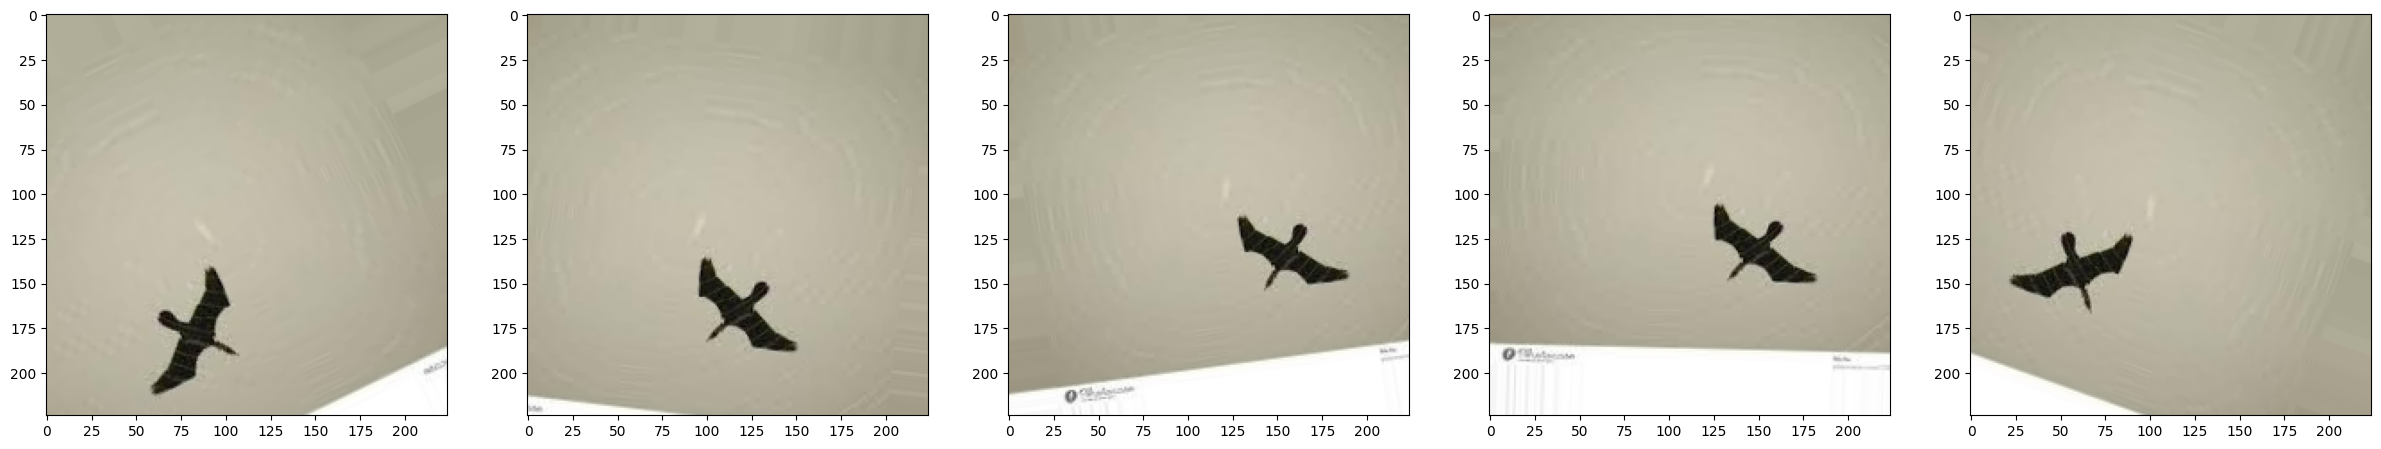

In [13]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(16, 224, 224, 3)
[0. 0. 1. 1. 1. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0.]


<Figure size 640x480 with 0 Axes>

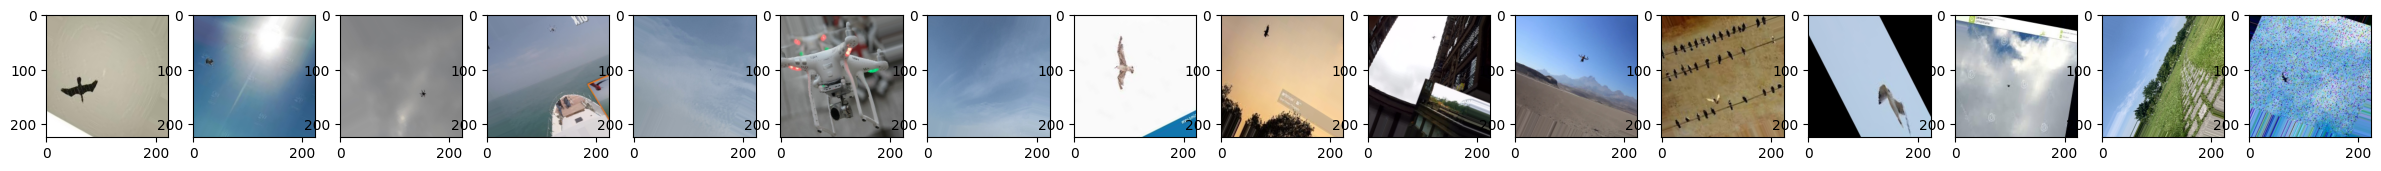

In [14]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 6))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [15]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary",
    shuffle = False)

Found 615 images belonging to 2 classes.


In [16]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary",
    shuffle = False)

Found 618 images belonging to 2 classes.


In [17]:
def getTransferredModelCompiled():
  # Load model
  base_model = InceptionV3(weights="imagenet", include_top=False, input_shape=(IMAGEWIDTH, IMAGEHEIGHT, 3))
  base_model.trainable = False ## Not trainable weights

  model = models.Sequential()
  model.add(base_model)
  model.add(layers.GlobalAveragePooling2D())
  model.add(layers.Dropout(0.16))
  model.add(layers.Dense(256,activation='relu'))
  model.add(layers.Dropout(0.16))
  model.add(layers.Dense(1,activation='sigmoid'))

  model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=LEARNINGRATE),
    metrics=["accuracy"])

  return model


In [18]:
InceptionModel = getTransferredModelCompiled()
InceptionModel.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ inception_v3 (Functional)       │ (None, 5, 5, 2048)     │    21,802,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,327,585 (85.17 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

In [19]:
%cd {parentDirectory}

/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual


In [20]:
%ls {parentDirectory}

 aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
 AviDetectClassifier.ipynb
 AviDetectPredict.ipynb
 BirdVSDrone/
'Captura de pantalla 2026-06-03 a la(s) 9.11.27 a.m..png'
 checkpoints/
 infer/
 models/


In [ ]:
!mkdir "models"

mkdir: cannot create directory ‘models’: File exists


In [21]:
modelDirectory = os.path.join(parentDirectory, "models")
checkpointInceptionModelPath = os.path.join(modelDirectory, "InceptionModel", "InceptionModel.keras")
checkpointInceptionModel = ModelCheckpoint(
    filepath = checkpointInceptionModelPath,
    save_weights_only = False,
    save_freq = "epoch",
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1)

In [22]:
InceptionModelHistory = InceptionModel.fit(
    trainGenerator,
    validation_data = valGenerator,
    epochs = EPOCHS,
    callbacks = [checkpointInceptionModel],
    verbose = True)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7861 - loss: 0.4385

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.61301, saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/models/InceptionModel/InceptionModel.keras

Epoch 1: finished saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/models/InceptionModel/InceptionModel.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1562s 7s/step - accuracy: 0.8764 - loss: 0.2996 - val_accuracy: 0.6130 - val_loss: 4.3403
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9394 - loss: 0.1676
Epoch 2: val_accuracy did not improve from 0.61301
219/219 ━━━━━━━━━━━━━━━━━━━━ 678s 3s/step - accuracy: 0.9479 - loss: 0.1505 - val_accuracy: 0.6049 - val_loss: 18.0314
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9526 - loss: 0.1322
Epoch 3: val_accuracy did not improve from 0.61301
219/219 ━━━━━━━━━━━━━━━━━━━━ 706s 3s/step - accuracy: 0.9574 - loss: 0.1169 - val_accuracy: 0.6016 

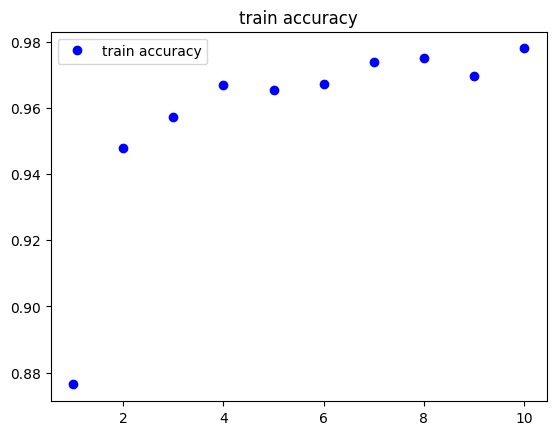

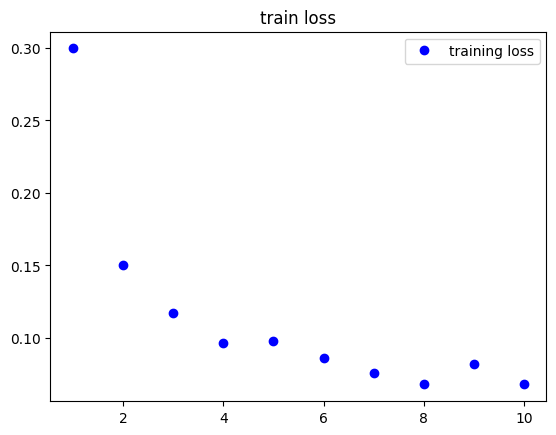

In [23]:
trainAccuracy = InceptionModelHistory.history["accuracy"]
trainLoss = InceptionModelHistory.history["loss"]

epochs = range(1, len(trainAccuracy)+1)

plt.plot(epochs, trainAccuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, trainLoss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

<Axes: >

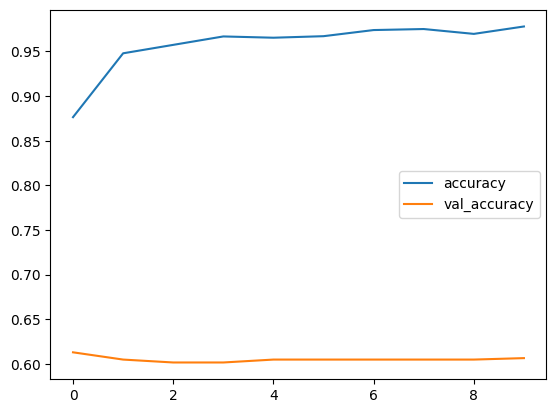

In [24]:
InceptionModelDF = pd.DataFrame(InceptionModelHistory.history)
InceptionModelDF.plot(y=["accuracy", "val_accuracy"])

In [25]:
# Inspect the model directory
!ls -lh {modelDirectory}

total 4.0K
drwx------ 2 root root 4.0K Jun  6 17:51 InceptionModel


In [26]:
InceptionModelBest = models.load_model(checkpointInceptionModelPath)

In [27]:
valLoss, valAccuracy = InceptionModelBest.evaluate(valGenerator)
print("\nval accuracy :\n", valAccuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 99s 2s/step - accuracy: 0.6130 - loss: 4.3403

val accuracy :
 0.6130081415176392


In [28]:
testLoss, testAccuracy = InceptionModelBest.evaluate(testGenerator)
print("\ntest acc :\n", testAccuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 209s 5s/step - accuracy: 0.5939 - loss: 4.8196

test acc :
 0.5938511490821838


## Comparando resultados
Compararemos resultados del mejor modelo que se obtuvo durante la historia

### Train

In [29]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", trainLoss, "\t", trainAccuracy)

Model		 Train loss		 Train Accuracy	
Original	 [0.2996308505535126, 0.15054437518119812, 0.11692455410957336, 0.09628866612911224, 0.09811492264270782, 0.085881806910038, 0.07549978792667389, 0.06837586313486099, 0.08184494078159332, 0.06788045167922974] 	 [0.8763948678970337, 0.9479256272315979, 0.9573676586151123, 0.9668097496032715, 0.9653791189193726, 0.9670958518981934, 0.9739627838134766, 0.9751073122024536, 0.9696709513664246, 0.9779685139656067]


219/219 ━━━━━━━━━━━━━━━━━━━━ 569s 3s/step
		 label negative label positive
prediction negative	 850 	 896
prediction positive	 823 	 926


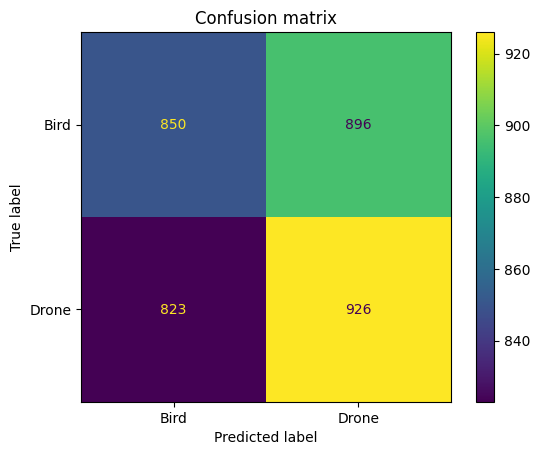

In [30]:
confusionMatrixTrain = confusionMatrix(InceptionModelBest, trainGenerator)
displayConfusionMatrix(confusionMatrixTrain)

In [31]:
metrics(confusionMatrixTrain)

Accuracy: 0.5082
Precision: 0.5082
Recall: 0.5294
F1-score: 0.5186


### Validation

In [32]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 4.340347766876221 	 0.6130081415176392


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step
		 label negative label positive
prediction negative	 88 	 153
prediction positive	 85 	 289


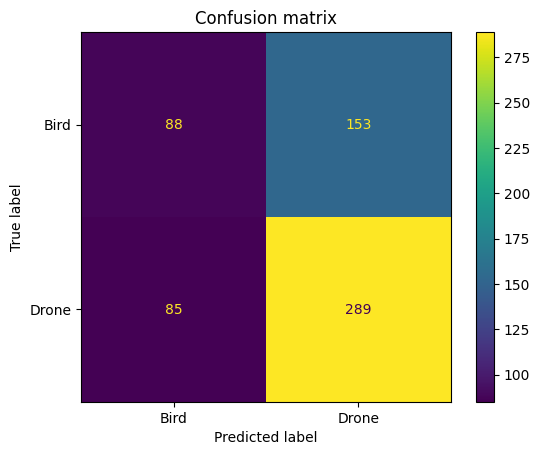

In [33]:
confusionMatrixVal = confusionMatrix(InceptionModelBest, valGenerator)
displayConfusionMatrix(confusionMatrixVal)

In [34]:
metrics(confusionMatrixVal)

Accuracy: 0.6130
Precision: 0.6538
Recall: 0.7727
F1-score: 0.7083


### Test

In [35]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 4.8195672035217285 	 0.5938511490821838


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step
		 label negative label positive
prediction negative	 77 	 165
prediction positive	 86 	 290


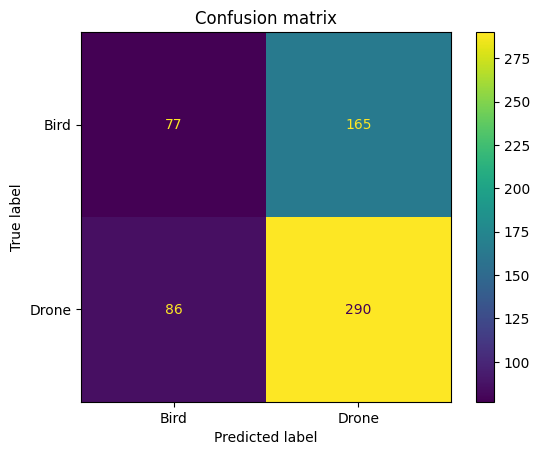

In [36]:
confusionMatrixTest = confusionMatrix(InceptionModelBest, testGenerator)
displayConfusionMatrix(confusionMatrixTest)

In [37]:
metrics(confusionMatrixTest)

Accuracy: 0.5939
Precision: 0.6374
Recall: 0.7713
F1-score: 0.6980


# Conclusiones

# Modelo con transfer learning (ResNet50)
Usamos el modelo ResNet50. La arquitectura Inception es una arquitectura utilizada en el campo del aprendizaje profundo y las redes neuronales convolucionales (CNN). Está diseñada para realizar tareas de extracción y clasificación de características de forma más eficiente. ResNet (Residual Networks) es una arquitectura de aprendizaje profundo diseñada para permitir el entrenamiento eficiente de redes neuronales muy profundas. Introduce conexiones de salto (o atajos), que permiten al modelo aprender mapeos residuales en lugar de transformaciones directas.


In [10]:
IMAGEWIDTH = 224
IMAGEHEIGHT = 224
BATCHSIZE = 16
ROTATIONRANGE = 30
TRANSLATIONS = 0.1
SCALING = [0.9, 1.1]
EPOCHS = 10
LEARNINGRATE = 0.0001

In [11]:
trainDatagen = ImageDataGenerator(
    rescale = 1.0/255,
    rotation_range = ROTATIONRANGE,
    width_shift_range = TRANSLATIONS,
    height_shift_range = TRANSLATIONS,
    zoom_range = SCALING,
    horizontal_flip = True,
    vertical_flip = False,
    featurewise_center = False)

Found 3495 images belonging to 2 classes.


<Figure size 640x480 with 0 Axes>

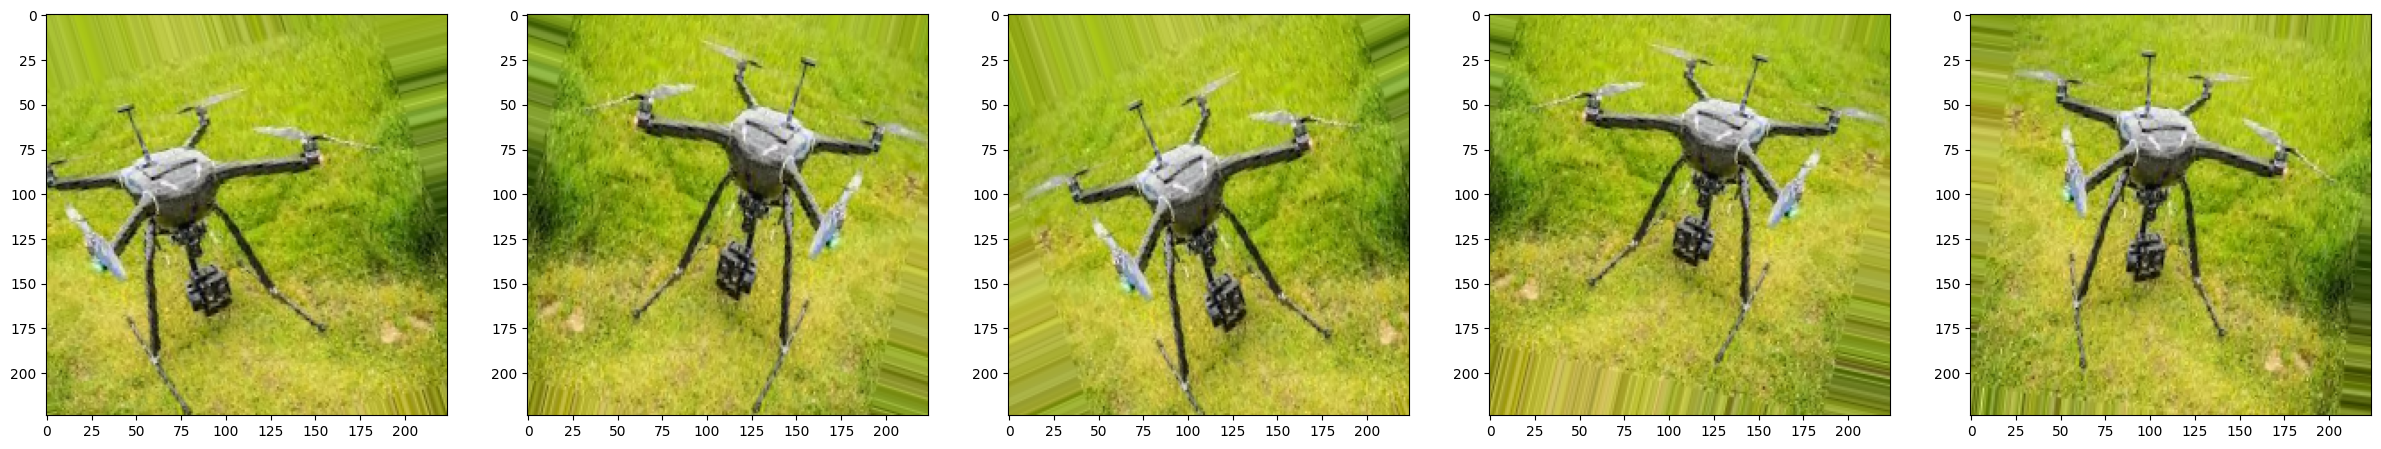

In [12]:
trainGenerator = trainDatagen.flow_from_directory(
    trainDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE, # Images that the models gets in each iteration
    class_mode = "binary") # Has to be the same on the last neuron of the model

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, 5, figsize=(30, 8))

for i in range(5) :
  axarr[i].imshow(trainGenerator[0][0][0])

(16, 224, 224, 3)
[1. 0. 0. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 1. 1.]


<Figure size 640x480 with 0 Axes>

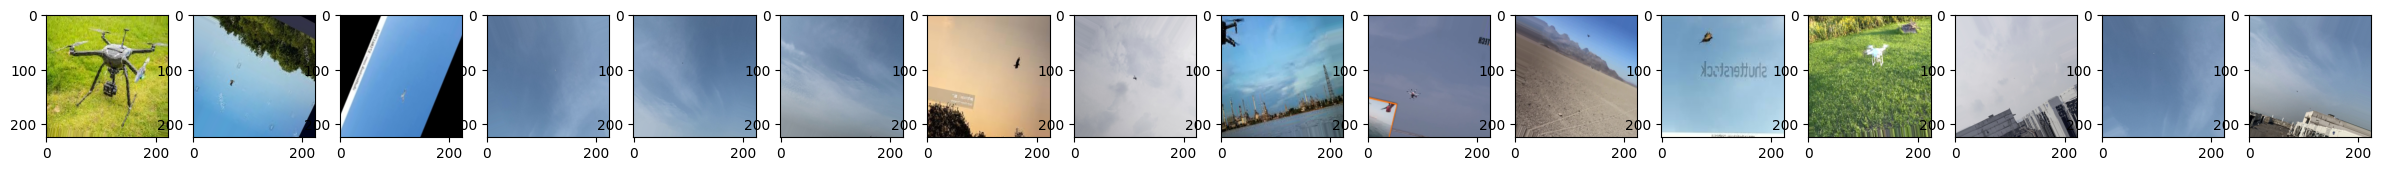

In [13]:
images , labels = trainGenerator[0]

print(images.shape)
print(labels)

plt.figure()
#subplot(r,c) provide the no. of rows and columns
f, axarr = plt.subplots(1, images.shape[0], figsize=(30, 6))

for i in range(images.shape[0]) :
  axarr[i].imshow(images[i])

In [14]:
valDatagen = ImageDataGenerator(1.0/255)
valGenerator = valDatagen.flow_from_directory(
    valDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode = "binary",
    shuffle = False)

Found 615 images belonging to 2 classes.


In [15]:
testDatagen = ImageDataGenerator(1.0/255)
testGenerator = testDatagen.flow_from_directory(
    testDirectory,
    target_size = (IMAGEWIDTH, IMAGEHEIGHT),
    batch_size = BATCHSIZE,
    class_mode= "binary",
    shuffle = False)

Found 618 images belonging to 2 classes.


In [16]:
def getResNetModelCompiled():
  # Load model
  base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(IMAGEWIDTH, IMAGEHEIGHT, 3))
  base_model.trainable = False ## Not trainable weights

  model = models.Sequential()
  model.add(base_model)
  model.add(layers.GlobalAveragePooling2D())
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(512,activation='relu'))
  model.add(layers.Dropout(0.2))
  model.add(layers.Dense(1,activation='sigmoid'))

  model.compile(
    loss="binary_crossentropy",
    optimizer=optimizers.Adam(learning_rate=LEARNINGRATE),
    metrics=["accuracy"])

  return model

In [17]:
ResNetModel = getResNetModelCompiled()
ResNetModel.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,637,313 (93.98 MB)

 Trainable params: 1,049,601 (4.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [18]:
%cd {parentDirectory}

/content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual


In [19]:
%ls {parentDirectory}

 aves-de-rapiña-presa-rapaces-depredador-tipos-buho-e1561932282180.jpg
 AviDetectClassifier.ipynb
 AviDetectPredict.ipynb
 BirdVSDrone/
'Captura de pantalla 2026-06-03 a la(s) 9.11.27 a.m..png'
 checkpoints/
 infer/
 models/


In [20]:
!mkdir "models"

mkdir: cannot create directory ‘models’: File exists


In [21]:
modelDirectory = os.path.join(parentDirectory, "models")
checkpointResNetModelPath = os.path.join(modelDirectory, "ResNetModel", "ResNetModel.keras")
checkpointResNetModel = ModelCheckpoint(
    filepath = checkpointResNetModelPath,
    save_weights_only = False,
    save_freq = "epoch",
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1)

In [22]:
ResNetModelHistory = ResNetModel.fit(
    trainGenerator,
    validation_data = valGenerator,
    epochs = EPOCHS,
    callbacks = [checkpointResNetModel],
    verbose = True)

Epoch 1/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.5148 - loss: 61.3298

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(



Epoch 1: val_accuracy improved from None to 0.46829, saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/models/ResNetModel/ResNetModel.keras

Epoch 1: finished saving model to /content/drive/MyDrive/8vo_semestre/AplicacionesAvanzadas/InteligenciaArtificial/ProyectoIndividual/models/ResNetModel/ResNetModel.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1242s 6s/step - accuracy: 0.5110 - loss: 45.0280 - val_accuracy: 0.4683 - val_loss: 20.3424
Epoch 2/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.5235 - loss: 14.7413
Epoch 2: val_accuracy did not improve from 0.46829
219/219 ━━━━━━━━━━━━━━━━━━━━ 114s 519ms/step - accuracy: 0.5202 - loss: 10.6392 - val_accuracy: 0.4000 - val_loss: 4.7326
Epoch 3/10
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.5173 - loss: 3.5161
Epoch 3: val_accuracy did not improve from 0.46829
219/219 ━━━━━━━━━━━━━━━━━━━━ 111s 508ms/step - accuracy: 0.5265 - loss: 2.6912 - val_accuracy: 0.41

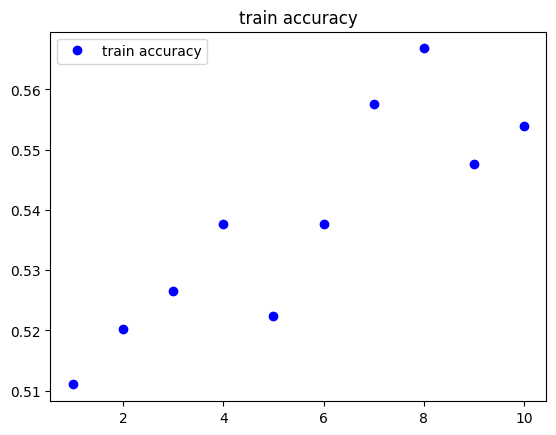

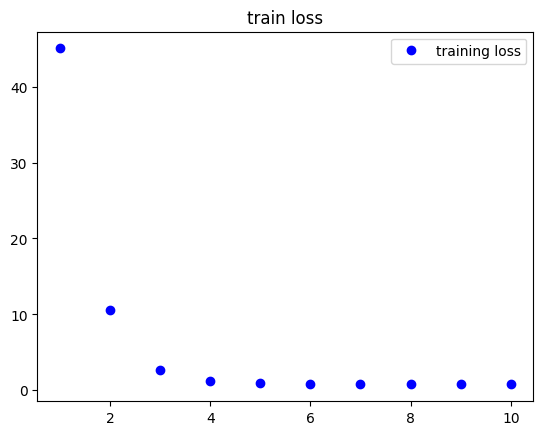

In [23]:
trainAccuracy = ResNetModelHistory.history["accuracy"]
trainLoss = ResNetModelHistory.history["loss"]

epochs = range(1, len(trainAccuracy)+1)

plt.plot(epochs, trainAccuracy, "bo", label="train accuracy")
plt.title("train accuracy")
plt.legend()

plt.figure()

plt.plot(epochs, trainLoss, "bo", label ="training loss")
plt.title("train loss")
plt.legend()

plt.show()

<Axes: >

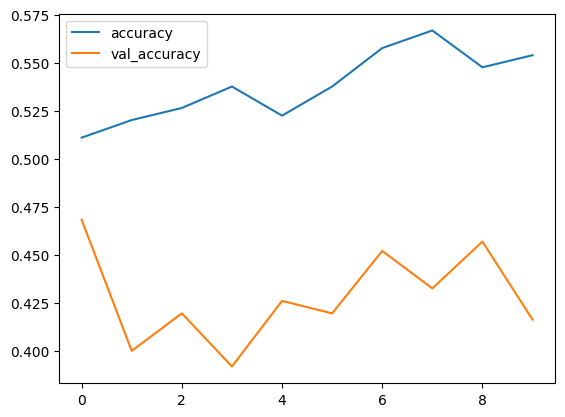

In [24]:
ResNetModelDF = pd.DataFrame(ResNetModelHistory.history)
ResNetModelDF.plot(y=["accuracy", "val_accuracy"])

In [25]:
# Inspect the model directory
!ls -lh {modelDirectory}

total 8.0K
drwx------ 2 root root 4.0K Jun  6 01:29 InceptionModel
drwx------ 2 root root 4.0K Jun  7 01:04 ResNetModel


In [26]:
ResNetModelBest = models.load_model(checkpointResNetModelPath)

In [27]:
valLoss, valAccuracy = ResNetModelBest.evaluate(valGenerator)
print("\nval accuracy :\n", valAccuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 21s 364ms/step - accuracy: 0.4683 - loss: 20.3424

val accuracy :
 0.4682926833629608


In [28]:
testLoss, testAccuracy = ResNetModelBest.evaluate(testGenerator)
print("\ntest acc :\n", testAccuracy)

39/39 ━━━━━━━━━━━━━━━━━━━━ 178s 5s/step - accuracy: 0.4466 - loss: 20.3524

test acc :
 0.446601927280426


## Comparando resultados
Compararemos resultados del mejor modelo que se obtuvo durante la historia

### Train

In [29]:
print("Model\t\t", "Train loss\t\t", "Train Accuracy\t")
print("Original\t", trainLoss, "\t", trainAccuracy)

Model		 Train loss		 Train Accuracy	
Original	 [45.028018951416016, 10.63920783996582, 2.691246509552002, 1.2013667821884155, 0.9472621083259583, 0.8686884641647339, 0.8236704468727112, 0.7982957363128662, 0.7843149900436401, 0.7649660110473633] 	 [0.5110157132148743, 0.5201717019081116, 0.5264663696289062, 0.5376251935958862, 0.5224606394767761, 0.5376251935958862, 0.5576537847518921, 0.5668097138404846, 0.5476394891738892, 0.5539342164993286]


219/219 ━━━━━━━━━━━━━━━━━━━━ 104s 458ms/step
		 label negative label positive
prediction negative	 1746 	 0
prediction positive	 1749 	 0


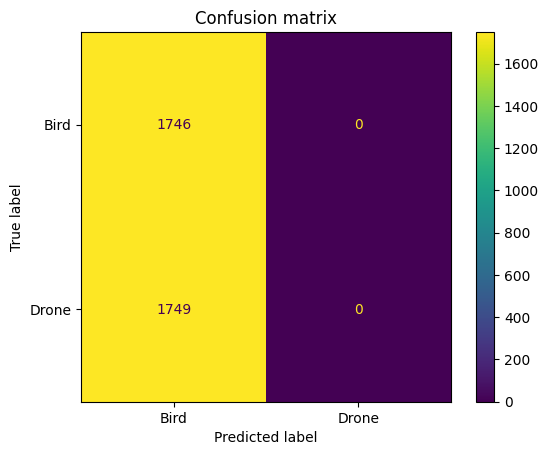

In [30]:
confusionMatrixTrain = confusionMatrix(ResNetModelBest, trainGenerator)
displayConfusionMatrix(confusionMatrixTrain)

In [31]:
metrics(confusionMatrixTrain)

Accuracy: 0.4996
Precision: nan
Recall: 0.0000
F1-score: nan


/tmp/ipykernel_526/1006062281.py:68: RuntimeWarning: invalid value encountered in scalar divide
  precision = truePositives / (truePositives + falsePositives)


### Validation

In [32]:
print("Model\t\t", "Val loss\t\t", "Val Accuracy\t")
print("Original\t", valLoss, "\t", valAccuracy)

Model		 Val loss		 Val Accuracy	
Original	 20.342418670654297 	 0.4682926833629608


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 13s 325ms/step
		 label negative label positive
prediction negative	 207 	 34
prediction positive	 293 	 81


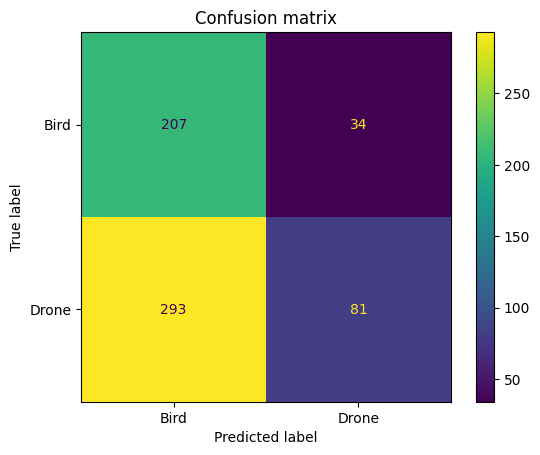

In [33]:
confusionMatrixVal = confusionMatrix(ResNetModelBest, valGenerator)
displayConfusionMatrix(confusionMatrixVal)

In [34]:
metrics(confusionMatrixVal)

Accuracy: 0.4683
Precision: 0.7043
Recall: 0.2166
F1-score: 0.3313


### Test

In [35]:
print("Model\t\t", "Test loss\t\t", "Test Accuracy\t")
print("Original\t", testLoss, "\t", testAccuracy)

Model		 Test loss		 Test Accuracy	
Original	 20.352352142333984 	 0.446601927280426


/usr/local/lib/python3.12/dist-packages/keras/src/legacy/preprocessing/image.py:1261: UserWarning: This ImageDataGenerator specifies `featurewise_center`, but it hasn't been fit on any training data. Fit it first by calling `.fit(numpy_data)`.
  warnings.warn(


39/39 ━━━━━━━━━━━━━━━━━━━━ 14s 364ms/step
		 label negative label positive
prediction negative	 205 	 37
prediction positive	 305 	 71


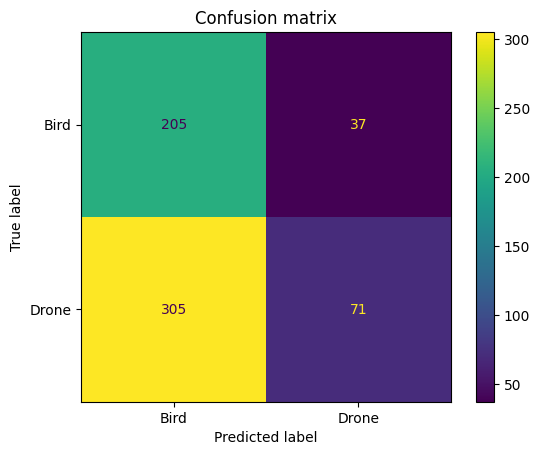

In [36]:
confusionMatrixTest = confusionMatrix(ResNetModelBest, testGenerator)
displayConfusionMatrix(confusionMatrixTest)

In [37]:
metrics(confusionMatrixTest)

Accuracy: 0.4466
Precision: 0.6574
Recall: 0.1888
F1-score: 0.2934
